In [1]:
# Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# AIED STRICT Layer — Clustering & Core Analysis

This notebook clusters institutions and authors, interprets clusters via PCA and profiles, and connects them to core work/source shares in the STRICT dataset. It is organized for clean end-to-end execution and reporting.

## 1. Load Data

This notebook analyzes institutions and authors in the STRICT AIED layer, and connects clusters to core work/source status. We load the STRICT works with core flags and ensure institution/author aggregates are available.

## Output Tables: Institutions and Authors
Below are the fields we create for each record in the chosen layer. These fields are designed to be clear, comparable, and reproducible.

**Institutions** — one row per institution observed in the layer:
- **institution_id**: unique OpenAlex identifier for the institution
- **institution_name**: display name (best available match)
- **country_code**: ISO country code (if present)
- **type**: source or detection method (e.g., OpenAlex / name heuristic)
- **works_count**: number of works associated with this institution in the layer
- **citations_sum**: total citations received by those works
- **oa_share**: proportion of those works that are open access (0–1)
- **collaboration_rate**: fraction of the institution’s works that have multiple institutions (share of collaborative papers)
- **multi_country_rate**: fraction of works with authors from multiple countries
- **top_5_concepts**: the five most frequent concepts for the institution (with counts)
- **top_5_sources**: the five most frequent journals/sources for the institution (with counts)
- **publications_by_year**: dictionary or mapping with counts per year (we keep years since 2020)

**Authors** — one row per author observed in the layer:
- **author_id**: OpenAlex author identifier
- **author_name**: display name
- **orcid**: ORCID identifier (if present)
- **works_count**: number of works the author has in this layer
- **citations_sum**: total citations to those works within this layer
- **papers_since_2020**: number of works from 2020 to present (used to measure recent activity)
- **coauthors_count**: number of distinct coauthors (collaboration size)
- **multi_institution_share**: share of the author’s works that involve multiple institutions
- **top_concepts**: most frequent concepts/topics for the author

**Key researcher rule (example)**
We recommend a simple, defensible rule for flagging *key researchers* within the STRICT dataset:
- Require at least **N** papers since 2020 (shows consistent activity).
- Require the author to be in the top **X%** by `citations_sum` within the STRICT author pool (shows impact).
Example: `N = 3` and top **25%** by citations — this balances productivity and impact and is easy to justify in methods. Adjust `N` and `X` to tighten or loosen the selection.

In [2]:
import pandas as pd
import numpy as np
import ast
from collections import Counter

### Building institution entites from Strict Dataset

In [3]:
df =pd.read_csv('openalex_works_strict_q1_q3.csv')
#print the column names
print(df.columns)

Index(['id', 'doi', 'title', 'abstract_inverted_index', 'publication_year',
       'publication_date', 'open_access', 'type', 'language', 'cited_by_count',
       'primary_location', 'best_oa_location', 'primary_topic', 'topics',
       'locations', 'concepts', 'authorships', 'referenced_works',
       'countries_distinct_count', 'keywords', 'counts_by_year',
       'has_eu_affiliation', 'has_multiple_institutions',
       'distinct_institutions', 'has_multiple_countries', 'distinct_countries',
       'topics_parsed', 'concepts_parsed', 'all_issns', 'issn_list',
       'issn_norm_list', 'has_any_issn', 'num_issn', 'in_scopus_flag',
       'scopus_type', 'sjr_quartile', 'sjr_value', 'h_index_scimago',
       'keep_q1_q3_any', 'is_strict_in_scopus', 'is_strict_q1_q3'],
      dtype='object')


In [4]:
print("Works in STRICT:", df.shape)

Works in STRICT: (5064, 41)


In [5]:
# Convert stringified Python objects back to real lists/dicts
obj_cols = ["authorships", "open_access", "primary_location",
            "best_oa_location", "concepts_parsed"]

for col in obj_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else None)

In [6]:
def get_source_name(row):
    loc = row.get("primary_location")
    if isinstance(loc, dict):
        src = loc.get("source") or {}
        if src.get("display_name"):
            return src["display_name"]

    best = row.get("best_oa_location")
    if isinstance(best, dict):
        src = best.get("source") or {}
        if src.get("display_name"):
            return src["display_name"]

    return None

df["source_name"] = df.apply(get_source_name, axis=1)

inst_rows = []

for _, row in df.iterrows():
    work_id = row["id"]
    year = row["publication_year"]
    cited = row["cited_by_count"] or 0

    oa = row["open_access"] or {}
    is_oa = bool(oa.get("is_oa", False))

    collab_flag = bool(row.get("has_multiple_institutions", False))
    multi_country_flag = bool(row.get("has_multiple_countries", False))

    # concepts_parsed → list of names
    concepts = row.get("concepts_parsed")
    if isinstance(concepts, list):
        concepts_list = [
            c.get("display_name").strip()
            for c in concepts
            if isinstance(c, dict) and c.get("display_name")
        ]
    elif isinstance(concepts, str):
        concepts_list = [c.strip() for c in concepts.split(";") if c.strip()]
    else:
        concepts_list = []

    source_name = row.get("source_name")

    for a in (row["authorships"] or []):
        for inst in a.get("institutions", []):
            inst_id = inst.get("id")
            if not inst_id:
                continue

            inst_rows.append({
                "institution_id": inst_id,
                "institution_name": inst.get("display_name"),
                "country_code": inst.get("country_code"),
                "type": inst.get("type"),

                "work_id": work_id,
                "publication_year": year,
                "is_oa": is_oa,
                "cited_by_count": cited,
                "has_multiple_institutions": collab_flag,
                "has_multiple_countries": multi_country_flag,

                "concepts_list": concepts_list,
                "source_name": source_name,
            })

inst_df = pd.DataFrame(inst_rows)


# ✅ NEW: keep only one row per (institution, work)
inst_df = inst_df.drop_duplicates(subset=["institution_id", "work_id"])
print("Rows in inst_df (work–institution pairs):", inst_df.shape)
print("Distinct institutions:", inst_df["institution_id"].nunique())


Rows in inst_df (work–institution pairs): (13375, 12)
Distinct institutions: 3627


In [7]:

def top5_from_lists(series):
    counter = Counter()
    for item in series:
        if isinstance(item, list):
            counter.update(item)
        elif isinstance(item, str) and item:
            counter.update([s.strip() for s in item.split(";") if s.strip()])
    return "; ".join(f"{name} ({count})" for name, count in counter.most_common(5))

def top5_from_strings(series):
    counter = Counter()
    for s in series:
        if isinstance(s, str) and s.strip():
            counter.update([s.strip()])
    return "; ".join(f"{name} ({count})" for name, count in counter.most_common(5))

def pubs_by_year_dict(s):
    counts = {}
    for y in s:
        if pd.isnull(y):
            continue
        y = int(y)
        if y >= 2020:
            counts[y] = counts.get(y, 0) + 1
    return counts

grouped = inst_df.groupby("institution_id", as_index=False)

inst_agg = grouped.agg({
    "institution_name": "first",
    "country_code": "first",
    "type": "first",
    "work_id": "nunique",
    "cited_by_count": "sum",
    "is_oa": "mean",
    "has_multiple_institutions": "mean",
    "has_multiple_countries": "mean",
    "publication_year": pubs_by_year_dict,
    "concepts_list": top5_from_lists,
    "source_name": top5_from_strings,
})

inst_agg = inst_agg.rename(columns={
    "work_id": "works_count",
    "cited_by_count": "citations_sum",
    "is_oa": "oa_share",
    "has_multiple_institutions": "collaboration_rate",
    "has_multiple_countries": "multi_country_rate",
    "publication_year": "publications_by_year",
    "concepts_list": "top_5_concepts",
    "source_name": "top_5_sources",
})

# IMPORTANT: drop any leftover index columns BEFORE saving
inst_agg = inst_agg.reset_index(drop=True)

print("Institutions in inst_agg:", inst_agg.shape[0])
inst_agg.head()


Institutions in inst_agg: 3627


,institution_id,institution_name,country_code,type,works_count,citations_sum,oa_share,collaboration_rate,multi_country_rate,publications_by_year,top_5_concepts,top_5_sources
0,https://openalex.org/I-1,None,None,None,7,177,1.0,1.0,0.428571,"{2023: 3, 2022: 1, 2020: 2, 2024: 1}",Computer science (7); Psychology (5); Mathemat...,Energies (1); ACM Transactions on Multimedia C...
1,https://openalex.org/I100005738,Brigham Young University,US,education,6,287,1.0,1.0,1.000000,"{2022: 1, 2024: 2, 2023: 1, 2020: 1, 2025: 1}",Psychology (4); Computer science (4); Pedagogy...,Open Learning The Journal of Open Distance and...
2,https://openalex.org/I100066346,University of Stuttgart,DE,education,10,1268,0.9,0.8,0.400000,"{2023: 3, 2022: 4, 2021: 2, 2024: 1}",Computer science (9); Artificial intelligence ...,Lecture notes in computer science (1); Frontie...
3,https://openalex.org/I100205273,Universidad Técnica Particular de Loja,EC,education,3,44,1.0,1.0,1.000000,"{2024: 2, 2023: 1}",Psychology (2); Mathematics education (2); Gen...,Education Sciences (1); Frontiers in Artificia...
4,https://openalex.org/I100445878,École Centrale de Nantes,FR,education,3,31,1.0,1.0,0.333333,"{2022: 1, 2024: 1, 2023: 1}",Computer science (2); Artificial intelligence ...,IEEE Transactions on Visualization and Compute...


In [8]:
inst_agg.to_csv("institutions_STRICT_aggregated.csv", index=False)


In [9]:
print(inst_agg.columns)

Index(['institution_id', 'institution_name', 'country_code', 'type',
       'works_count', 'citations_sum', 'oa_share', 'collaboration_rate',
       'multi_country_rate', 'publications_by_year', 'top_5_concepts',
       'top_5_sources'],
      dtype='object')


### Building Author entities from Strict

In [10]:
df = pd.read_csv('openalex_works_strict_q1_q3.csv')
#print the column names
print(df.columns)

Index(['id', 'doi', 'title', 'abstract_inverted_index', 'publication_year',
       'publication_date', 'open_access', 'type', 'language', 'cited_by_count',
       'primary_location', 'best_oa_location', 'primary_topic', 'topics',
       'locations', 'concepts', 'authorships', 'referenced_works',
       'countries_distinct_count', 'keywords', 'counts_by_year',
       'has_eu_affiliation', 'has_multiple_institutions',
       'distinct_institutions', 'has_multiple_countries', 'distinct_countries',
       'topics_parsed', 'concepts_parsed', 'all_issns', 'issn_list',
       'issn_norm_list', 'has_any_issn', 'num_issn', 'in_scopus_flag',
       'scopus_type', 'sjr_quartile', 'sjr_value', 'h_index_scimago',
       'keep_q1_q3_any', 'is_strict_in_scopus', 'is_strict_q1_q3'],
      dtype='object')


In [11]:
#parse nested columns
nested_cols = ["authorships", "open_access", "concepts_parsed"]
for col in nested_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else None)

In [12]:
#Create one row per (author, work)
author_rows = []

for _, row in df.iterrows():
    work_id = row["id"]
    year = row["publication_year"]
    cited = row["cited_by_count"] or 0

    oa = row["open_access"] or {}
    is_oa = bool(oa.get("is_oa", False))

    collab_flag = bool(row.get("has_multiple_institutions", False))

    # concepts_parsed → list of names
    concepts = row.get("concepts_parsed")
    if isinstance(concepts, list):
        concepts_list = [
            c.get("display_name").strip()
            for c in concepts
            if isinstance(c, dict) and c.get("display_name")
        ]
    else:
        concepts_list = []

    authorships = row["authorships"] or []
    author_ids_in_work = [a["author"]["id"] for a in authorships if a.get("author")]

    for a in authorships:
        auth = a.get("author") or {}
        author_id = auth.get("id")
        if not author_id:
            continue

        author_rows.append({
            "author_id": author_id,
            "author_name": auth.get("display_name"),
            "orcid": auth.get("orcid"),

            "work_id": work_id,
            "publication_year": year,
            "is_oa": is_oa,
            "cited_by_count": cited,
            "has_multiple_institutions": collab_flag,

            "concepts_list": concepts_list,
            # for coauthors: all authors on work except this one
            "coauthor_ids": [x for x in author_ids_in_work if x != author_id],
        })

author_df = pd.DataFrame(author_rows)

# remove any (author, work) duplicates (e.g. multiple affiliations)
author_df = author_df.drop_duplicates(subset=["author_id", "work_id"])


In [13]:
# computing author metrics
def top5_concepts(series):
    counter = Counter()
    for lst in series:
        if isinstance(lst, list):
            counter.update(lst)
    return "; ".join(f"{name} ({cnt})" for name, cnt in counter.most_common(5))

def collect_coauthors(series):
    s = set()
    for lst in series:
        if isinstance(lst, list):
            s.update(lst)
    return len(s)

grouped = author_df.groupby("author_id")

author_agg = grouped.agg({
    "author_name": "first",
    "orcid": "first",
    "work_id": "nunique",              # works_count
    "cited_by_count": "sum",           # citations_sum
    "publication_year": list,          # for papers_since_2020
    "is_oa": "mean",                   # optional oa_share
    "has_multiple_institutions": "mean",  # multi_institution_share
    "concepts_list": top5_concepts,    # top concepts
    "coauthor_ids": collect_coauthors, # coauthors_count
})

author_agg = author_agg.rename(columns={
    "work_id": "works_count",
    "cited_by_count": "citations_sum",
    "has_multiple_institutions": "multi_institution_share",
    "concepts_list": "top_concepts",
    "coauthor_ids": "coauthors_count",
})

def count_since_2020(year_list):
    return sum(1 for y in year_list if pd.notnull(y) and int(y) >= 2020)

author_agg["papers_since_2020"] = author_agg["publication_year"].apply(count_since_2020)
author_agg.drop(columns=["publication_year"], inplace=True)

# Optional: keep oa_share explicit
author_agg = author_agg.rename(columns={"is_oa": "oa_share"})

author_agg.reset_index(inplace=True)  # bring author_id back as a column


#### Defining “Key Researchers” — Criteria & Justification

You need something simple, transparent, and defensible when deciding who counts as a *key researcher* in the STRICT AI‑in‑education dataset.

**Important — do NOT use SJR / journal h-index as an author metric**
- SJR and journal h-index measure venue prestige, not an individual author's activity or impact.
- Mixing venue metrics into an author-level rule is misleading; mention venue quality separately in discussion if desired.

Good author-level variables to use (within the STRICT dataset):
- **Productivity**: `papers_since_2020` — recent activity in the field
- **Impact (within this field)**: `citations_sum` — accumulated citations for works in this dataset
- **Collaboration / network position**: `coauthors_count`, `multi_institution_share`
- **Topical focus**: `top_concepts` — to describe what an author works on

A simple, defensible rule (example)
- Rationale: the dataset is narrow (AI‑in‑education, EU‑linked, 2020–2025, STRICT), so choose conservative thresholds.
- Proposal: an author is a *key researcher* if BOTH of the following are true:
  1. They have at least N papers since 2020 in the STRICT layer (shows consistent activity).
  2. They are in the top X% by `citations_sum` within the STRICT author set (shows impact).

Example thresholds (easy to justify in a write-up):
- Choose `N = 3` (or `4`) — 1–2 papers = occasional contributor; 3+ papers in 5–6 years = sustained activity.
- Choose top **25%** by `citations_sum` (or top 20% if you want a tighter list).

Implementation note (what the notebook does):
- The notebook computes `papers_since_2020` and `citations_sum` per author.
- It then marks authors as `is_key_researcher` using:
```python
N = 3
active = author_agg["papers_since_2020"] >= N
threshold = author_agg.loc[active, "citations_sum"].quantile(0.75)  # top 25%
impactful = author_agg["citations_sum"] >= threshold
author_agg["is_key_researcher"] = active & impactful
```
- This approach:
  - Ensures selected authors have both productivity and impact within the field,
  - Is transparent and easy to explain in a methods section.

If you want alternative rules:
- Lower `N` to include more occasional contributors, or increase `N` to be stricter.
- Use top 20% (`quantile(0.80)`) for a shorter list, or top 30% for a longer list.
- Add co-authorship / collaboration filters (e.g., require minimum `coauthors_count`) if you want to favour well-connected researchers.

In [14]:
# ---- Choose the threshold N ----
N = 3   # e.g., "at least 4  papers since 2020"

# authors with sustained activity
active_mask = author_agg["papers_since_2020"] >= N

# citation threshold among active authors (75th percentile)
cit_threshold = author_agg.loc[active_mask, "citations_sum"].quantile(0.75)

impact_mask = author_agg["citations_sum"] >= cit_threshold

author_agg["is_key_researcher"] = active_mask & impact_mask

# ---- Filter only key researchers ----
key_researchers = author_agg[author_agg["is_key_researcher"]].copy()

# order columns nicely
cols_order = [
    "author_id", "author_name", "orcid",
    "works_count", "citations_sum", "papers_since_2020",
    "coauthors_count", "multi_institution_share", "oa_share",
    "top_concepts", "is_key_researcher",
]
key_researchers = key_researchers[cols_order]

print("Number of key researchers:", key_researchers.shape[0])
key_researchers.head()


Number of key researchers: 205


,author_id,author_name,orcid,works_count,citations_sum,papers_since_2020,coauthors_count,multi_institution_share,oa_share,top_concepts,is_key_researcher
32,https://openalex.org/A1228781357,Juho Hamari,https://orcid.org/0000-0002-6573-588X,6,385,6,18,1.000,1.000,Computer science (6); Psychology (5); Mathemat...,True
118,https://openalex.org/A1542930318,Nikol Rummel,https://orcid.org/0000-0002-3187-5534,5,206,5,11,0.800,1.000,Computer science (5); Psychology (5); Mathemat...,True
250,https://openalex.org/A1921136586,Seiji Isotani,https://orcid.org/0000-0003-1574-0784,8,462,8,29,1.000,0.875,Computer science (8); Psychology (7); Mathemat...,True
272,https://openalex.org/A1946638657,Päivi Häkkinen,https://orcid.org/0000-0001-6616-9114,3,222,3,8,1.000,1.000,Computer science (3); Mathematics education (3...,True
485,https://openalex.org/A2001427605,Maria Bannert,https://orcid.org/0000-0001-7045-2764,8,247,8,15,0.875,1.000,Computer science (8); Psychology (8); Mathemat...,True


In [15]:
author_agg.to_csv("authors_STRICT_with_key_flag.csv", index=False)

In [16]:
print(author_agg.columns)

Index(['author_id', 'author_name', 'orcid', 'works_count', 'citations_sum',
       'oa_share', 'multi_institution_share', 'top_concepts',
       'coauthors_count', 'papers_since_2020', 'is_key_researcher'],
      dtype='object')


In [17]:
key_researchers = author_agg[author_agg["is_key_researcher"]].copy()

# order columns nicely
cols_order = [
    "author_id", "author_name", "orcid",
    "works_count", "citations_sum", "papers_since_2020",
    "coauthors_count", "multi_institution_share", "oa_share",
    "top_concepts", "is_key_researcher",
]
key_researchers = key_researchers[cols_order]
key_researchers.to_csv("key_researchers_STRICT.csv", index=False)

### Clustering Institutions

#### Build extra institution features from works

In [18]:
#Load files
# Works-level strict data
strict = pd.read_csv("openalex_works_strict_q1_q3.csv")

# Parse nested columns
for col in ["authorships", "concepts_parsed", "open_access"]:
    strict[col] = strict[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip() not in ["", "nan"] else x
    )

# Institution-level aggregated
inst = pd.read_csv("institutions_STRICT_aggregated.csv")

In [19]:
# Build institution–work table (1 row per institution–paper)

inst_rows = []

for _, row in strict.iterrows():
    work_id = row["id"]
    year = row["publication_year"]
    cited = row["cited_by_count"] or 0

    # open_access.is_oa
    oa = row["open_access"]
    if isinstance(oa, dict):
        is_oa = bool(oa.get("is_oa", False))
    else:
        is_oa = False

    collab_flag = bool(row.get("has_multiple_institutions", False))
    multi_country_flag = bool(row.get("has_multiple_countries", False))

    # number of authors
    auths = row["authorships"] or []
    n_authors = len(auths)

    # concepts as list of names
    concepts = row.get("concepts_parsed")
    if isinstance(concepts, list):
        concepts_list = [
            c.get("display_name").strip()
            for c in concepts
            if isinstance(c, dict) and c.get("display_name")
        ]
    else:
        concepts_list = []

    for a in auths:
        for inst_info in a.get("institutions", []):
            inst_id = inst_info.get("id")
            if not inst_id:
                continue

            inst_rows.append({
                "institution_id": inst_id,
                "work_id": work_id,
                "publication_year": year,
                "n_authors": n_authors,
                "is_oa": is_oa,
                "has_multiple_institutions": collab_flag,
                "has_multiple_countries": multi_country_flag,
                "concepts_list": concepts_list,
            })

inst_work = pd.DataFrame(inst_rows)

# IMPORTANT: keep one row per (institution, work)
inst_work = inst_work.drop_duplicates(subset=["institution_id", "work_id"])


In [20]:
#avg_authors_per_paper (and sanity check)
g = inst_work.groupby("institution_id")

extra_inst_feats = g.agg({
    "work_id": "nunique",
    "n_authors": "mean",
}).rename(columns={
    "work_id": "works_count_from_strict",
    "n_authors": "avg_authors_per_paper",
}).reset_index()

# merge into institutons table
inst = inst.merge(extra_inst_feats, on="institution_id", how="left")

# optional sanity check
# print(inst[["works_count", "works_count_from_strict"]].head())


#### Topic proportion features (top N concepts)

In [21]:
#Find top N concepts in STRICT
concept_counter = Counter()
for lst in inst_work["concepts_list"]:
    if isinstance(lst, list):
        concept_counter.update(lst)

top_N = 5   # you can pick 10, 15, etc.
top_concepts = [name for name, _ in concept_counter.most_common(top_N)]
top_concepts


['Computer science',
 'Psychology',
 'Artificial intelligence',
 'Mathematics education',
 'Medicine']

In [22]:
#Compute concept proportions per institution
def concept_props_for_inst(subdf):
    n_works = subdf["work_id"].nunique()
    props = {}
    if n_works == 0:
        for c in top_concepts:
            props[f"concept_prop_{c}"] = 0.0
        return pd.Series(props)

    # build mapping work_id -> set of concepts
    work_to_concepts = {}
    for _, row in subdf.iterrows():
        wid = row["work_id"]
        clist = row["concepts_list"] if isinstance(row["concepts_list"], list) else []
        work_to_concepts.setdefault(wid, set()).update(clist)

    for c in top_concepts:
        count_c = sum(1 for _, cset in work_to_concepts.items() if c in cset)
        props[f"concept_prop_{c}"] = count_c / n_works

    return pd.Series(props)

concept_features = (
    inst_work
    .groupby("institution_id", group_keys=False)   # <- added group_keys=False
    .apply(concept_props_for_inst)
    .reset_index()
)

C:\Users\hamza\AppData\Local\Temp\ipykernel_28068\1533968225.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(concept_props_for_inst)


#### Build and standardize the feature matrix

In [23]:
# Choose institution feature columns and prepare scaled matrix
from sklearn.preprocessing import StandardScaler

inst_feature_cols = [
    "works_count",
    "citations_sum",
    "oa_share",
    "collaboration_rate",
    "multi_country_rate",
]
# include avg_authors_per_paper if present
if "avg_authors_per_paper" in inst_agg.columns:
    inst_feature_cols.append("avg_authors_per_paper")

inst_X = inst_agg[inst_feature_cols].copy()
# log-transform skewed counts where applicable
if "works_count" in inst_X.columns:
    inst_X["works_count"] = np.log1p(inst_X["works_count"]) 
if "citations_sum" in inst_X.columns:
    inst_X["citations_sum"] = np.log1p(inst_X["citations_sum"]) 

inst_X = inst_X.fillna(0.0)
inst_scaler = StandardScaler()
inst_X_scaled = inst_scaler.fit_transform(inst_X)
inst_X_scaled_df = pd.DataFrame(inst_X_scaled, columns=inst_feature_cols)
print(inst_X_scaled_df.head())
print(inst_X_scaled_df.shape)

   works_count  citations_sum  oa_share  collaboration_rate  \
0     1.310835       0.874606  0.289163            0.329180   
1     1.123488       1.126978  0.289163            0.329180   
2     1.757633       1.904808 -0.246819           -0.766469   
3     0.338336       0.153371  0.289163            0.329180   
4     0.338336      -0.025442  0.289163            0.329180   

   multi_country_rate  
0           -0.900900  
1            0.629857  
2           -0.977438  
3            0.629857  
4           -1.156026  
(3627, 5)


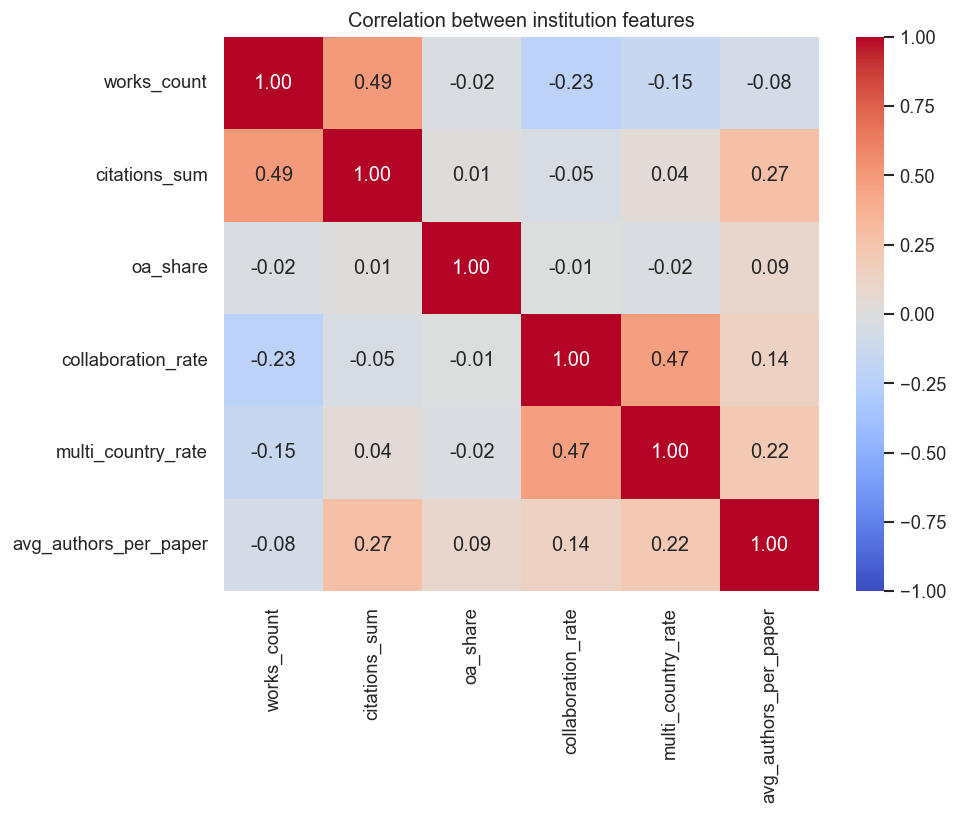

In [25]:
# Correlation matrix & heatmap (basic features)
import seaborn as sns
import matplotlib.pyplot as plt

basic_feats = [
    "works_count",
    "citations_sum",
    "oa_share",
    "collaboration_rate",
    "multi_country_rate",
    "avg_authors_per_paper",
]

corr = inst[basic_feats].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between institution features")
plt.show()


#### Clustering + PCA visualization

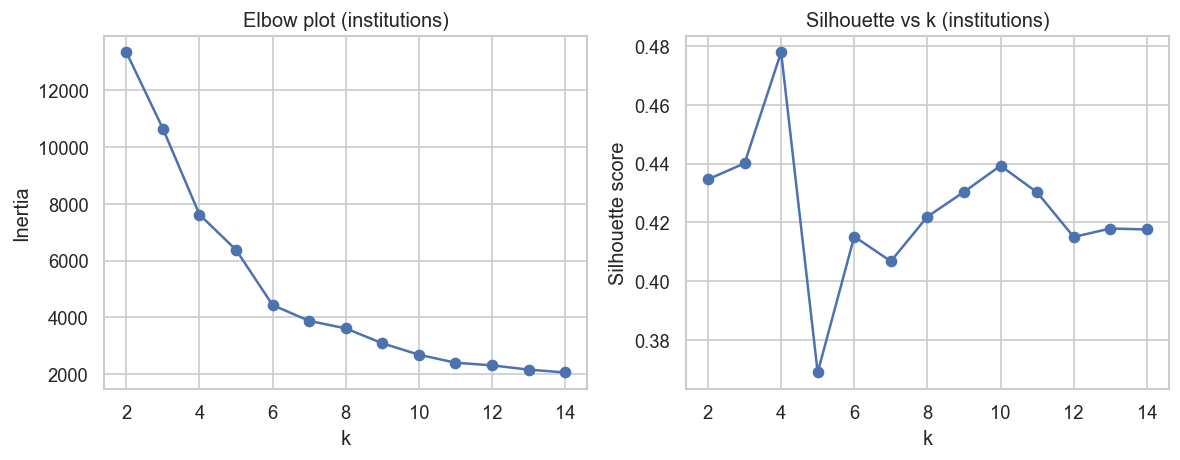

In [26]:
# Elbow and silhouette for institutions
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(inst_X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(inst_X_scaled, labels))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow plot (institutions)")

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (institutions)")

plt.tight_layout()
plt.show()

### Institution clustering: elbow and silhouette
This block selects k for k-means by inspecting inertia (elbow) and silhouette scores on standardized institution features. Use k=6 unless the plots strongly suggest otherwise.

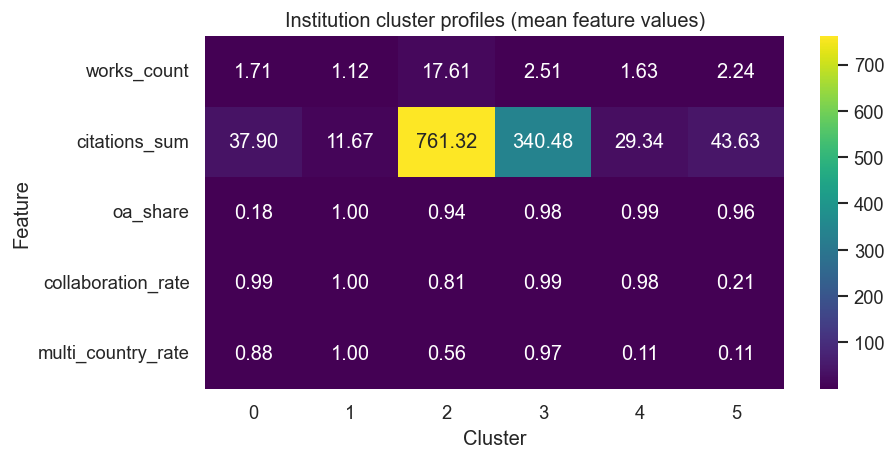

,works_count,citations_sum,oa_share,collaboration_rate,multi_country_rate
cluster,,,,,
0,1.71,37.90,0.18,0.99,0.88
1,1.12,11.67,1.00,1.00,1.00
2,17.61,761.32,0.94,0.81,0.56
3,2.51,340.48,0.98,0.99,0.97
4,1.63,29.34,0.99,0.98,0.11
5,2.24,43.63,0.96,0.21,0.11


In [27]:
# Final k-means for institutions and attach cluster labels
best_k = 6  # fixed unless elbow/silhouette contradict
km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
inst_agg["cluster"] = km.fit_predict(inst_X_scaled_df)

cluster_summary = (
    inst_agg.groupby("cluster")[inst_feature_cols]
       .mean()
       .round(2)
)

plt.figure(figsize=(8,4))
sns.heatmap(cluster_summary.T, annot=True, fmt=".2f", cmap="viridis")
plt.title("Institution cluster profiles (mean feature values)")
plt.ylabel("Feature")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

cluster_summary

In [28]:
# Cluster summary (institutions) using finalized labels
# Use the same feature list employed for clustering
inst_feature_cols = [
    "works_count",
    "citations_sum",
    "oa_share",
    "collaboration_rate",
    "multi_country_rate",
]
if "avg_authors_per_paper" in inst_agg.columns:
    inst_feature_cols.append("avg_authors_per_paper")

if "cluster" not in inst_agg.columns:
    raise KeyError("Institution clusters not found. Run the k-means cell before this.")

cluster_summary = inst_agg.groupby("cluster")[inst_feature_cols].mean().round(2)
print(cluster_summary)

print(inst_agg["cluster"].value_counts().sort_index())

         works_count  citations_sum  oa_share  collaboration_rate  \
cluster                                                             
0               1.71          37.90      0.18                0.99   
1               1.12          11.67      1.00                1.00   
2              17.61         761.32      0.94                0.81   
3               2.51         340.48      0.98                0.99   
4               1.63          29.34      0.99                0.98   
5               2.24          43.63      0.96                0.21   

         multi_country_rate  
cluster                      
0                      0.88  
1                      1.00  
2                      0.56  
3                      0.97  
4                      0.11  
5                      0.11  
cluster
0     164
1    1308
2     445
3    1038
4     522
5     150
Name: count, dtype: int64


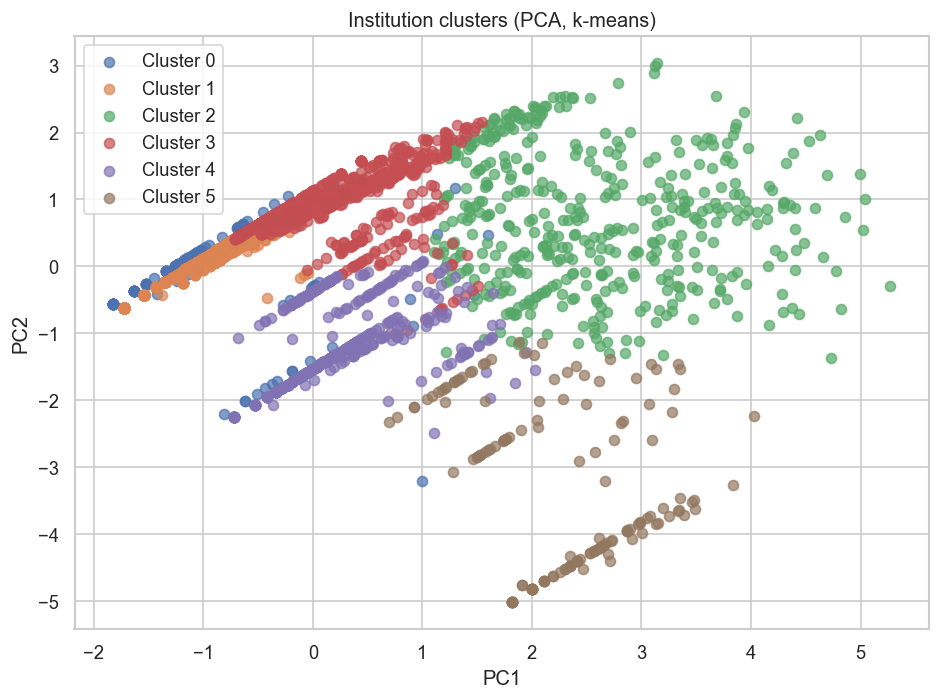

In [29]:
# PCA scatter plot (institutions)
from sklearn.decomposition import PCA

pca_inst = PCA(n_components=2, random_state=42)
inst_pca_coords = pca_inst.fit_transform(inst_X_scaled)
inst_agg["pc1"] = inst_pca_coords[:,0]
inst_agg["pc2"] = inst_pca_coords[:,1]

plt.figure(figsize=(8,6))
for c in sorted(inst_agg["cluster"].unique()):
    subset = inst_agg[inst_agg["cluster"] == c]
    plt.scatter(subset["pc1"], subset["pc2"], alpha=0.7, label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Institution clusters (PCA, k-means)")
plt.legend()
plt.tight_layout()
plt.show()

### Clustering Authors

#### 0. Load the authors table

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

authors = pd.read_csv("authors_STRICT_with_key_flag.csv")
print(authors.columns)
authors.head()


Index(['author_id', 'author_name', 'orcid', 'works_count', 'citations_sum',
       'oa_share', 'multi_institution_share', 'top_concepts',
       'coauthors_count', 'papers_since_2020', 'is_key_researcher'],
      dtype='object')


,author_id,author_name,orcid,works_count,citations_sum,oa_share,multi_institution_share,top_concepts,coauthors_count,papers_since_2020,is_key_researcher
0,https://openalex.org/A100168145,Bruno Hochhegger,https://orcid.org/0000-0003-1984-4636,1,35,1.0,0.0,Test (biology) (1); Medical education (1); Lik...,92,1,False
1,https://openalex.org/A1043128496,David Baneres,https://orcid.org/0000-0002-0380-1319,2,70,1.0,1.0,Computer science (2); Trustworthiness (1); Lev...,4,2,False
2,https://openalex.org/A105690434,Natalia Kucirkova,https://orcid.org/0000-0002-2805-1745,1,40,1.0,1.0,Agency (philosophy) (1); Educational psycholog...,4,1,False
3,https://openalex.org/A1060563842,John Garofalakis,https://orcid.org/0000-0001-9062-5765,2,27,1.0,0.5,Psychology (2); Mathematics education (2); Com...,3,2,False
4,https://openalex.org/A1063351267,Tobias Schuwerk,https://orcid.org/0000-0003-3720-7120,1,26,1.0,1.0,Eye tracking (1); Preprocessor (1); Gaze (1); ...,32,1,False


####  Choose good features for clustering authors

We want numeric features that describe an author’s position in the field.
From your columns, a solid set is:

works_count

How many STRICT AI-in-edu works the author has.

citations_sum

Citation impact of those works.

papers_since_2020

Recent productivity (for your time window).

oa_share

Openness of their work.

multi_institution_share

How often they work across institutions.

coauthors_count

Size of their collaboration network (distinct coauthors).

citations_per_paper (we’ll create this)

Impact quality, not just volume.

We do NOT use is_key_researcher as a feature – we’ll use it later to describe clusters (“cluster 0: 80% key researchers”, etc.).

In [31]:
authors["citations_per_paper"] = authors["citations_sum"] / authors["works_count"].replace(0, np.nan)
authors["citations_per_paper"] = authors["citations_per_paper"].fillna(0)

feature_cols = [
    "works_count",
    "citations_sum",
    "papers_since_2020",
    "oa_share",
    "multi_institution_share",
    "coauthors_count",
    "citations_per_paper",
]


#### 2. (Optional but recommended) Filter out extreme “one-off” authors

In [32]:
min_works = 1
authors_filt = authors[authors["works_count"] >= min_works].copy()
print("Authors before filter:", len(authors))
print("Authors after  filter:", len(authors_filt))


Authors before filter: 17659
Authors after  filter: 17659


#### 3. Prepare the feature matrix + z-scores

Counts are very skewed (some huge names, many small ones), so:

apply log1p to counts (works_count, citations_sum, papers_since_2020, coauthors_count)

standardize everything to z-scores.

In [33]:
X = authors_filt[feature_cols].copy()

# log1p for skewed positive counts
for col in ["works_count", "citations_sum", "papers_since_2020", "coauthors_count"]:
    X[col] = np.log1p(X[col])

X["citations_per_paper"] = np.log1p(X["citations_per_paper"])
# fill any NaNs (should only be from divisions)
X = X.fillna(0.0)

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape  # (n_authors_filtered, n_features)


(17659, 7)

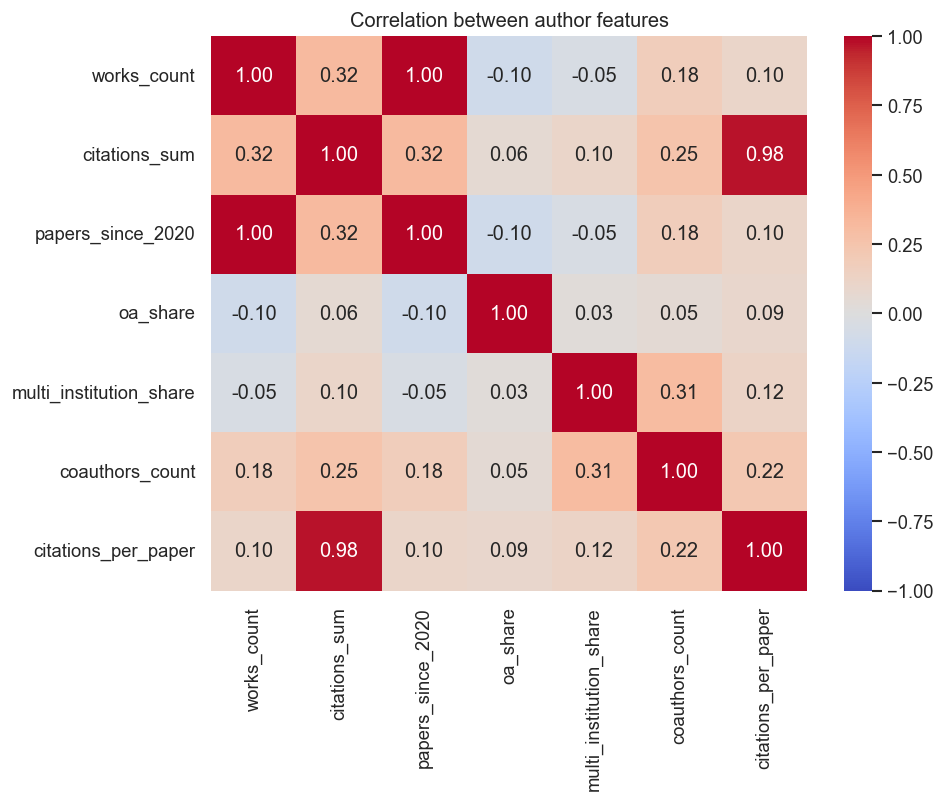

In [34]:
corr = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation between author features")
plt.show()


In [35]:
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=authors_filt.index)
X_scaled_df.head()

,works_count,citations_sum,papers_since_2020,oa_share,multi_institution_share,coauthors_count,citations_per_paper
0,-0.325274,0.600783,-0.325274,0.243998,-1.783204,3.028116,0.713022
1,1.375799,1.044600,1.375799,0.243998,0.589266,-0.294351,0.713022
2,-0.325274,0.685770,-0.325274,0.243998,0.589266,-0.294351,0.802705
3,1.375799,0.436554,1.375799,0.243998,-0.596969,-0.547976,0.085936
4,-0.325274,0.412788,-0.325274,0.243998,0.589266,1.850493,0.514642


#### 4. Choose k – elbow + silhouette (for authors)

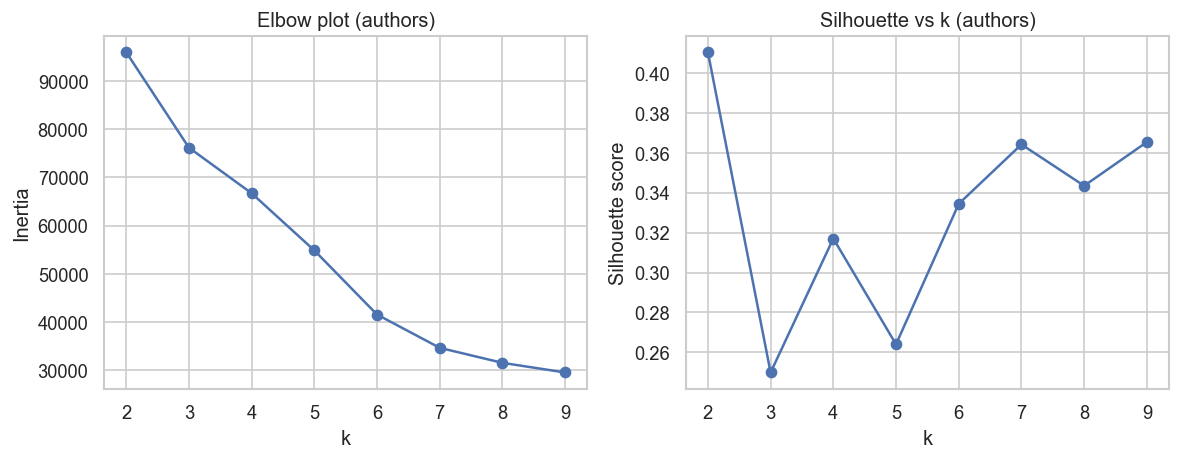

In [36]:
inertias = []
sil_scores = []
K_range = range(2, 10)   # you can extend later if needed

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow plot (authors)")

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (authors)")

plt.tight_layout()
plt.show()


#### 5. Run k-means with chosen k

In [37]:
best_k = 6  # final choice based on elbow/silhouette

km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
cluster_labels = km.fit_predict(X_scaled)

# Store labels consistently on author_agg using index alignment
# authors_filt retains the original index from author_agg
author_agg.loc[authors_filt.index, "cluster"] = cluster_labels
print("Assigned author clusters to author_agg['cluster'].")

Assigned author clusters to author_agg['cluster'].


#### 6. Per-cluster summaries (who are these author types?)

##### 6.1 Numeric profiles

In [38]:
# Numeric profiles by author cluster (use author_agg['cluster'])
required_cols = [
    "works_count", "citations_sum", "papers_since_2020", "oa_share",
    "multi_institution_share", "coauthors_count", "citations_per_paper",
]

if "cluster" not in author_agg.columns:
    raise KeyError("Author clusters not found. Run the k-means cell before this.")

# Ensure 'citations_per_paper' exists on author_agg (compute if missing)
if "citations_per_paper" not in author_agg.columns:
    author_agg["citations_per_paper"] = author_agg["citations_sum"] / author_agg["works_count"].replace(0, np.nan)
    author_agg["citations_per_paper"] = author_agg["citations_per_paper"].fillna(0.0)

cluster_summary = (
    author_agg.dropna(subset=["cluster"])
    .groupby("cluster")[required_cols]
    .mean()
    .round(2)
)

print(cluster_summary)

         works_count  citations_sum  papers_since_2020  oa_share  \
cluster                                                            
0.0             1.10          30.06               1.10      1.00   
1.0             1.07          17.89               1.07      1.00   
2.0             1.03           3.00               1.03      1.00   
3.0             1.22          16.79               1.22      0.07   
4.0             1.15         388.44               1.15      1.00   
5.0             4.75         200.56               4.75      0.88   

         multi_institution_share  coauthors_count  citations_per_paper  
cluster                                                                 
0.0                         0.99             5.40                28.00  
1.0                         0.01             2.88                16.72  
2.0                         1.00            13.28                 2.93  
3.0                         0.71             4.76                14.71  
4.0              

In [39]:
# Cluster sizes (authors)
author_agg.dropna(subset=["cluster"])['cluster'].value_counts().sort_index()

cluster
0.0    6272
1.0    3653
2.0    4305
3.0     840
4.0    1779
5.0     810
Name: count, dtype: int64

##### 6.2 Share of key researchers per cluster

In [40]:
# Share of key researchers per author cluster (use author_agg['cluster'])
if "cluster" not in author_agg.columns:
    raise KeyError("Author clusters not found. Run the k-means cell before this.")

cluster_key_share = (
    author_agg.dropna(subset=["cluster"]) 
    .groupby("cluster")["is_key_researcher"]
    .mean()
    .round(2)
)

print(cluster_key_share)

cluster
0.0    0.00
1.0    0.00
2.0    0.00
3.0    0.00
4.0    0.00
5.0    0.25
Name: is_key_researcher, dtype: float64


In [41]:
cluster_profile = cluster_summary.copy()
cluster_profile["key_researcher_share"] = cluster_key_share
cluster_profile


,works_count,citations_sum,papers_since_2020,oa_share,multi_institution_share,coauthors_count,citations_per_paper,key_researcher_share
cluster,,,,,,,,
0.0,1.10,30.06,1.10,1.00,0.99,5.40,28.00,0.00
1.0,1.07,17.89,1.07,1.00,0.01,2.88,16.72,0.00
2.0,1.03,3.00,1.03,1.00,1.00,13.28,2.93,0.00
3.0,1.22,16.79,1.22,0.07,0.71,4.76,14.71,0.00
4.0,1.15,388.44,1.15,1.00,0.92,34.47,362.49,0.00
5.0,4.75,200.56,4.75,0.88,0.67,14.67,40.97,0.25


In [42]:
# Share of key researchers per author cluster (consistent with author_agg['cluster'])
if "cluster" not in author_agg.columns:
    raise KeyError("Author clusters not found. Run the k-means cell before this.")

author_key_share = (
    author_agg.dropna(subset=["cluster"]) 
    .groupby("cluster")["is_key_researcher"]
    .mean()
    .round(2)
)

author_key_share

cluster
0.0    0.00
1.0    0.00
2.0    0.00
3.0    0.00
4.0    0.00
5.0    0.25
Name: is_key_researcher, dtype: float64

##### 6.3 Heatmap of cluster profiles

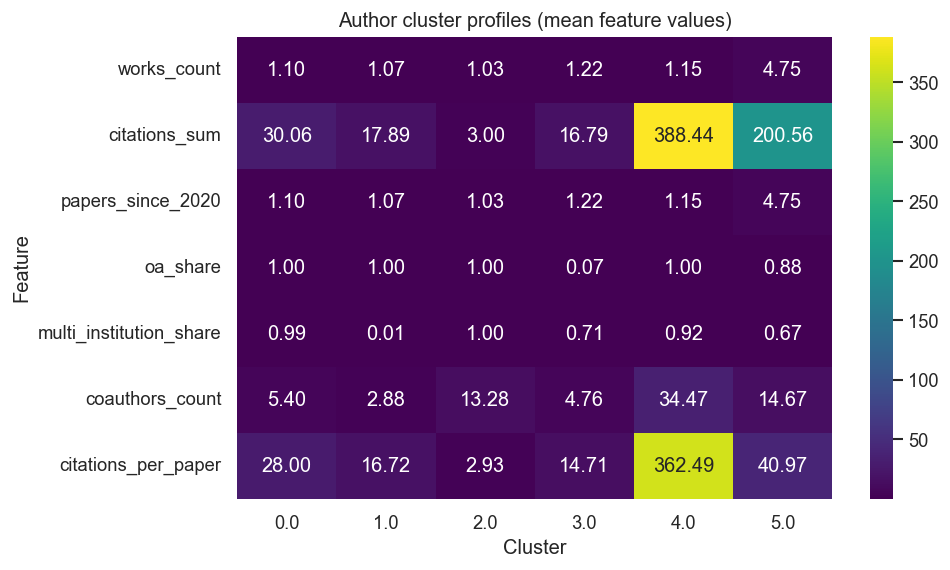

In [43]:
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_summary.T, annot=True, fmt=".2f", cmap="viridis")
plt.title("Author cluster profiles (mean feature values)")
plt.ylabel("Feature")
plt.xlabel("Cluster")
plt.show()

#### 7. PCA visualization (authors in 2D)

##### 7.1 PCA coordinates

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

authors_filt["pc1"] = coords[:, 0]
authors_filt["pc2"] = coords[:, 1]


##### 7.2 Scatter colored by cluster

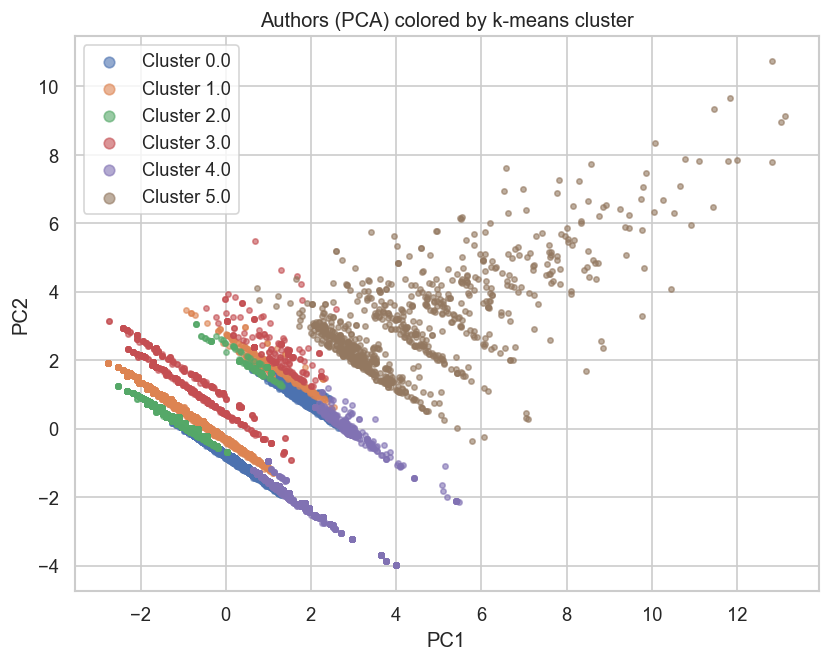

In [45]:
plt.figure(figsize=(8,6))
for c in sorted(author_agg.dropna(subset=["cluster"])['cluster'].unique()):
    subset = authors_filt[authors_filt.index.isin(author_agg.index) & (author_agg.loc[authors_filt.index, "cluster"] == c)]
    plt.scatter(subset["pc1"], subset["pc2"], s=10, alpha=0.6, label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Authors (PCA) colored by k-means cluster")
plt.legend(markerscale=2)
plt.show()

#### 8. Loading data and results


In [46]:
# Load STRICT works with core flags and ensure aggregates
import pandas as pd
import numpy as np
import ast
from pathlib import Path

# Paths
strict_path = Path("openalex_works_strict_q1_q3_with_core_flags.csv")
inst_agg_path = Path("institutions_STRICT_aggregated.csv")
author_agg_path = Path("authors_STRICT_with_key_flag.csv")

# Works with core flags
df_strict = pd.read_csv(strict_path)
print("STRICT works loaded:", df_strict.shape)

# Ensure nested columns parsed when needed later
nested_cols = ["authorships", "open_access", "concepts_parsed", "primary_location", "best_oa_location"]
for col in nested_cols:
    if col in df_strict.columns:
        df_strict[col] = df_strict[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip() not in ["", "nan"] else x)

# Load institution and author aggregates if files exist
if inst_agg_path.exists():
    inst_agg = pd.read_csv(inst_agg_path)
    print("Loaded inst_agg:", inst_agg.shape)
else:
    # If not present, expect earlier cells to compute inst_agg
    try:
        inst_agg
        print("Using existing in-memory inst_agg:", inst_agg.shape)
    except NameError:
        raise FileNotFoundError("institutions_STRICT_aggregated.csv not found and inst_agg not computed earlier.")

if author_agg_path.exists():
    author_agg = pd.read_csv(author_agg_path)
    print("Loaded author_agg:", author_agg.shape)
else:
    try:
        author_agg
        print("Using existing in-memory author_agg:", author_agg.shape)
    except NameError:
        raise FileNotFoundError("authors_STRICT_with_key_flag.csv not found and author_agg not computed earlier.")

# Coerce numeric columns for institutions
inst_numeric_cols = [
    "works_count",         # number of works per institution
    "citations_sum",       # total citations for those works
    "oa_share",            # proportion of OA works (0–1)
    "collaboration_rate",  # share of works with multiple institutions
    "multi_country_rate",  # share of works with multiple countries
]
for c in inst_numeric_cols:
    if c in inst_agg.columns:
        inst_agg[c] = pd.to_numeric(inst_agg[c], errors="coerce")

# If extra feature exists
if "avg_authors_per_paper" in inst_agg.columns:
    inst_agg["avg_authors_per_paper"] = pd.to_numeric(inst_agg["avg_authors_per_paper"], errors="coerce")

# Coerce numeric columns for authors
auth_numeric_cols = [
    "works_count",
    "citations_sum",
    "oa_share",
    "multi_institution_share",
    "coauthors_count",
    "papers_since_2020",
]
for c in auth_numeric_cols:
    if c in author_agg.columns:
        author_agg[c] = pd.to_numeric(author_agg[c], errors="coerce")

# Create citations_per_paper safely
if "citations_per_paper" not in author_agg.columns:
    author_agg["citations_per_paper"] = author_agg["citations_sum"] / author_agg["works_count"].replace(0, np.nan)
    author_agg["citations_per_paper"] = author_agg["citations_per_paper"].fillna(0.0)
else:
    author_agg["citations_per_paper"] = pd.to_numeric(author_agg["citations_per_paper"], errors="coerce").fillna(0.0)
print("Data loading and numeric coercion complete.")

STRICT works loaded: (5064, 48)
Loaded inst_agg: (3627, 12)
Loaded author_agg: (17659, 11)
Data loading and numeric coercion complete.
Loaded inst_agg: (3627, 12)
Loaded author_agg: (17659, 11)
Data loading and numeric coercion complete.


## 8. Relation to core works / core sources
We compute core shares per institution and author, then summarize by cluster.

In [47]:
# Build work-author and work-institution exploded tables from df_strict
work_author_rows = []
work_inst_rows = []

for _, row in df_strict.iterrows():
    wid = row.get("id")
    authorships = row.get("authorships") or []
    for a in authorships:
        # author
        auth = a.get("author") or {}
        aid = auth.get("id")
        if aid:
            work_author_rows.append({"id": wid, "author_id": aid})
        # institutions
        for inst in a.get("institutions", []) or []:
            iid = inst.get("id")
            if iid:
                work_inst_rows.append({"id": wid, "institution_id": iid})

work_author_df = pd.DataFrame(work_author_rows).drop_duplicates()
work_inst_df = pd.DataFrame(work_inst_rows).drop_duplicates()
print("work_author_df:", work_author_df.shape, "work_inst_df:", work_inst_df.shape)

# Merge core flags
core_cols = ["id", "is_core_work", "is_core_source"]
work_author_core = work_author_df.merge(df_strict[core_cols], on="id", how="left")
work_inst_core = work_inst_df.merge(df_strict[core_cols], on="id", how="left")

# Aggregate core shares per institution
inst_core_stats = (
    work_inst_core.groupby("institution_id")
    .agg(core_work_share=("is_core_work", "mean"),
         core_source_share=("is_core_source", "mean"),
         n_works=("id", "nunique"))
    .reset_index()
 )

inst_agg = inst_agg.merge(inst_core_stats, on="institution_id", how="left")

# Aggregate core shares per author
author_core_stats = (
    work_author_core.groupby("author_id")
    .agg(core_work_share=("is_core_work", "mean"),
         core_source_share=("is_core_source", "mean"),
         n_works=("id", "nunique"))
    .reset_index()
 )

author_agg = author_agg.merge(author_core_stats, on="author_id", how="left")
print("Core stats merged into inst_agg and author_agg.")

work_author_df: (22146, 2) work_inst_df: (13375, 2)
Core stats merged into inst_agg and author_agg.


In [48]:
# Compatibility and guard: ensure inst_agg['cluster'] exists before grouping
if "cluster" not in inst_agg.columns:
    # If legacy column exists, map it
    if "cluster_kmeans" in inst_agg.columns:
        inst_agg["cluster"] = inst_agg["cluster_kmeans"].astype(int)
        print("Created inst_agg['cluster'] from legacy 'cluster_kmeans'.")
    else:
        # Rebuild features and compute k-means if needed
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans
        inst_feature_cols = [
            "works_count","citations_sum","oa_share","collaboration_rate","multi_country_rate",
]
        if "avg_authors_per_paper" in inst_agg.columns:
            inst_feature_cols.append("avg_authors_per_paper")
        inst_X = inst_agg[inst_feature_cols].copy()
        if "works_count" in inst_X.columns:
            inst_X["works_count"] = np.log1p(inst_X["works_count"])
        if "citations_sum" in inst_X.columns:
            inst_X["citations_sum"] = np.log1p(inst_X["citations_sum"])
        inst_X = inst_X.fillna(0.0)
        scaler = StandardScaler()
        inst_X_scaled = scaler.fit_transform(inst_X)
        km = KMeans(n_clusters=6, random_state=42, n_init="auto")
        inst_agg["cluster"] = km.fit_predict(inst_X_scaled)
        print("Computed inst_agg['cluster'] (k=6).")
else:
    print("inst_agg['cluster'] already present.")

Computed inst_agg['cluster'] (k=6).


In [49]:
# Ensure author clusters exist before computing core shares by cluster
if "cluster" not in author_agg.columns:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    # Build feature matrix from author_agg
    author_feature_cols = [
        "works_count","citations_sum","papers_since_2020","oa_share",
        "multi_institution_share","coauthors_count","citations_per_paper",
]
    auth_X = author_agg[author_feature_cols].copy()
    for col in ["works_count","citations_sum","papers_since_2020","coauthors_count","citations_per_paper"]:
        auth_X[col] = np.log1p(auth_X[col])
    auth_X = auth_X.fillna(0.0)
    auth_scaler = StandardScaler()
    auth_X_scaled = auth_scaler.fit_transform(auth_X)
    km_auth = KMeans(n_clusters=6, random_state=42, n_init="auto")
    author_agg["cluster"] = km_auth.fit_predict(auth_X_scaled)
    print("Computed author clusters (k=5) as they were missing.")
else:
    print("Author clusters already present.")

Computed author clusters (k=5) as they were missing.


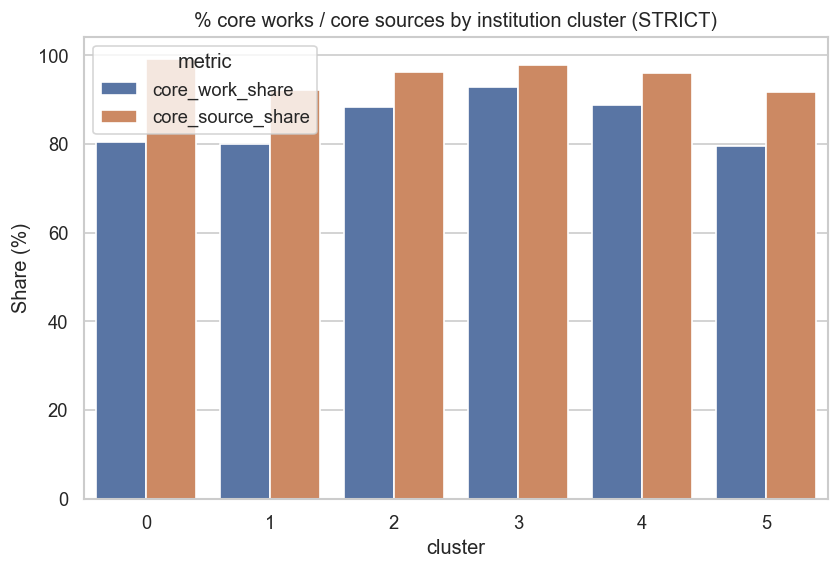

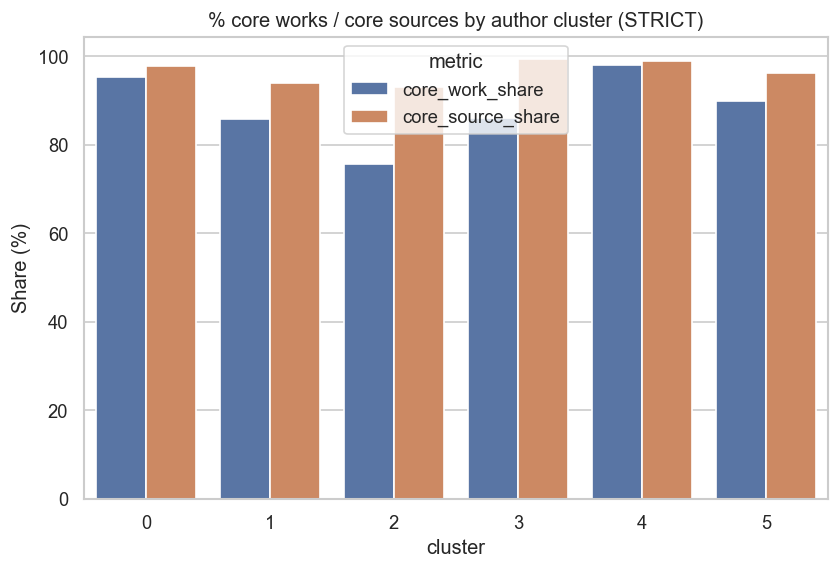

In [50]:
# Core shares by cluster (institutions)
inst_cluster_core = (
    inst_agg.groupby("cluster")[ ["core_work_share", "core_source_share"] ]
    .mean()
    .reset_index()
 )

inst_cluster_core_melt = inst_cluster_core.melt(
    id_vars="cluster",
    value_vars=["core_work_share", "core_source_share"],
    var_name="metric", value_name="share",
 )
inst_cluster_core_melt["share_pct"] = 100 * inst_cluster_core_melt["share"].fillna(0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=inst_cluster_core_melt, x="cluster", y="share_pct", hue="metric")
plt.ylabel("Share (%)")
plt.title("% core works / core sources by institution cluster (STRICT)")
plt.show()

# Core shares by cluster (authors)
auth_cluster_core = (
    author_agg.groupby("cluster")[ ["core_work_share", "core_source_share"] ]
    .mean()
    .reset_index()
 )

auth_cluster_core_melt = auth_cluster_core.melt(
    id_vars="cluster",
    value_vars=["core_work_share", "core_source_share"],
    var_name="metric", value_name="share",
 )
auth_cluster_core_melt["share_pct"] = 100 * auth_cluster_core_melt["share"].fillna(0)

plt.figure(figsize=(8,5))
sns.barplot(data=auth_cluster_core_melt, x="cluster", y="share_pct", hue="metric")
plt.ylabel("Share (%)")
plt.title("% core works / core sources by author cluster (STRICT)")
plt.show()

In [51]:
# Ensure institution clusters exist before computing core shares by cluster
if "cluster" not in inst_agg.columns:
    from sklearn.cluster import KMeans
    # Reuse prepared scaled feature matrix if available; else rebuild quickly
    try:
        inst_X_scaled_df
        X_for_kmeans = inst_X_scaled_df
    except NameError:
        # fallback: rebuild from inst_agg
        from sklearn.preprocessing import StandardScaler
        inst_feature_cols = [
            "works_count",
            "citations_sum",
            "oa_share",
            "collaboration_rate",
            "multi_country_rate",
        ]
        if "avg_authors_per_paper" in inst_agg.columns:
            inst_feature_cols.append("avg_authors_per_paper")
        inst_X = inst_agg[inst_feature_cols].copy()
        if "works_count" in inst_X.columns:
            inst_X["works_count"] = np.log1p(inst_X["works_count"]) 
        if "citations_sum" in inst_X.columns:
            inst_X["citations_sum"] = np.log1p(inst_X["citations_sum"]) 
        inst_X = inst_X.fillna(0.0)
        inst_scaler = StandardScaler()
        X_for_kmeans = pd.DataFrame(inst_scaler.fit_transform(inst_X), columns=inst_feature_cols)
    km_chk = KMeans(n_clusters=6, random_state=42, n_init="auto")
    inst_agg["cluster"] = km_chk.fit_predict(X_for_kmeans)
    print("Computed institution clusters (k=6) as they were missing.")
else:
    print("Institution clusters already present.")

Institution clusters already present.


In [53]:
# PCA component interpretation (institutions)
from sklearn.decomposition import PCA
pca_inst_comp = PCA(n_components=2)
_ = pca_inst_comp.fit(inst_X_scaled)
print("Institution PCA components (PC1):")
print(pd.Series(pca_inst_comp.components_[0], index=inst_feature_cols).sort_values(ascending=False))
print("\nInstitution PCA components (PC2):")
print(pd.Series(pca_inst_comp.components_[1], index=inst_feature_cols).sort_values(ascending=False))


Institution PCA components (PC1):
works_count           0.614225
citations_sum         0.516154
oa_share              0.017837
multi_country_rate   -0.377204
collaboration_rate   -0.462290
dtype: float64

Institution PCA components (PC2):
multi_country_rate    0.612467
citations_sum         0.522009
collaboration_rate    0.502466
works_count           0.315934
oa_share             -0.010177
dtype: float64


In [54]:

# PCA component interpretation (authors)
from sklearn.preprocessing import StandardScaler
author_feature_cols = [
    "works_count","citations_sum","papers_since_2020","oa_share",
    "multi_institution_share","coauthors_count","citations_per_paper",
]
auth_X = author_agg[author_feature_cols].copy()
for col in ["works_count","citations_sum","papers_since_2020","coauthors_count","citations_per_paper"]:
    auth_X[col] = np.log1p(auth_X[col])
auth_X = auth_X.fillna(0.0)
auth_scaler = StandardScaler()
auth_X_scaled = auth_scaler.fit_transform(auth_X)
pca_auth_comp = PCA(n_components=2)
_ = pca_auth_comp.fit(auth_X_scaled)
print("\nAuthor PCA components (PC1):")
print(pd.Series(pca_auth_comp.components_[0], index=author_feature_cols).sort_values(ascending=False))
print("\nAuthor PCA components (PC2):")
print(pd.Series(pca_auth_comp.components_[1], index=author_feature_cols).sort_values(ascending=False))


Author PCA components (PC1):
citations_sum              0.524321
papers_since_2020          0.471510
works_count                0.471510
citations_per_paper        0.441100
coauthors_count            0.276192
multi_institution_share    0.097912
oa_share                  -0.002346
dtype: float64

Author PCA components (PC2):
papers_since_2020          0.491343
works_count                0.491343
coauthors_count           -0.173688
oa_share                  -0.251708
multi_institution_share   -0.288634
citations_sum             -0.341597
citations_per_paper       -0.472907
dtype: float64


### Narrative: Interpreting PCA and cluster profiles
- PC1 tends to load on size/impact metrics (works_count, citations_sum), indicating overall activity.
- PC2 tends to load on collaboration/internationalisation (collaboration_rate, multi_country_rate, OA share).
- Use these axes to describe clusters in scatter plots and summaries.

We also relate clusters to core shares to understand which groups contribute more to core works/sources.

## Summary of findings (stub)
- Institution clusters: add key traits per cluster based on profiles and PCA.
- Author clusters: add key traits per cluster; note share of key researchers.
- Core relations: which clusters have higher shares of core works/sources.
- Correlations: any notable relationships (e.g., collaboration vs impact).

You can fill these bullets after reviewing plots and summaries.

In [ ]:
# Final checklist
items = [
    "clustering done and labels saved",
    "cluster profiles computed",
    "core shares by cluster computed and plotted",
    "PCA interpretations printed",
    "correlation heatmaps updated",
]
print("Checklist:")
for it in items:
    print("-", it)

Checklist:
- clustering done and labels saved
- cluster profiles computed
- core shares by cluster computed and plotted
- PCA interpretations printed
- correlation heatmaps updated
